# Calogero-Sutherland model in a harmonic trap (1D)

`N` particles on a line, harmonically trapped, interacting through the inverse-square
Calogero-Sutherland potential. In the code convention $\hbar^2/m = 1$ (kinetic
$=-\sum_i\partial_i^2$, **not** $-\tfrac12\partial_i^2$):

$$ H = -\sum_i \frac{\partial^2}{\partial x_i^2} + \sum_i x_i^2 + 2L(L-1)\sum_{i<j}\frac{1}{(x_i-x_j)^2} $$

**Exact ground state** (Calogero):

$$ \psi_0(x) = C \prod_{i<j}|x_i-x_j|^{L}\,\exp\!\Big(-\tfrac12\sum_i x_i^2\Big),\qquad \log|\psi_0| = L\sum_{i<j}\log|x_i-x_j| - \tfrac12\sum_i x_i^2 $$

**Exact energy** (in this $\omega=1$ convention):
$$ E_0 = N\big(1 + L(N-1)\big), \qquad E_0/N = 1 + L(N-1). $$

This is the CS analogue of the `soft_sphere_gas` notebook: a **parametrised setup** that
builds the `CalogeroSutherlandHamiltonian`, trains an ansatz, and wraps everything in
`run_cs(...)` so you can scan the coupling `L` (or `N`) and compare against the exact $E_0$.

All machinery lives in `qvarnet`:
`qvarnet.hamiltonian.continuous.CalogeroSutherlandHamiltonian`,
`qvarnet.models.analytic.CalogeroSutherlandAnalyticModel`, and `LogJastrow`.

## Imports

In [1]:
%matplotlib inline

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
import flax.linen as nn

from qvarnet.train import train
from qvarnet.config.training_setup import TrainingConfig
from qvarnet.config.coord_mode import LabCoords
from qvarnet.boundaries import NoBoundary
from qvarnet.models.compose import LogWavefunction
from qvarnet.models.mlp import MLP
from qvarnet.models.envelopes import GaussianEnvelope
from qvarnet.models.jastrow import LogJastrow
from qvarnet.models.analytic import CalogeroSutherlandAnalyticModel
from qvarnet.hamiltonian.continuous import CalogeroSutherlandHamiltonian

## 0. Parameters

`L` is the CS coupling (the exact Jastrow exponent $\lambda = L$). `L>1` is repulsive,
`L<1` attractive (and harder). The interaction strength is $g = 2L(L-1)$.

In [3]:
N      = 30          # number of particles
N_DIM  = 1          # CS is a 1-D model
L      = 0.8        # CS coupling (THE scan knob); exact lambda = L
EPS    = 1e-12      # softens the 1/(x_i-x_j)^2 singularity (small but nonzero)

DoF = N * N_DIM
E_exact_total = N * (1 + L * (N - 1))          # code convention, omega=1
E_exact_per_n = E_exact_total / N
print(f'N={N}, L={L}  ->  g = 2L(L-1) = {2*L*(L-1):.3f}')
print(f'Exact E0 = {E_exact_total:.4f}   (E0/N = {E_exact_per_n:.4f})')

N=30, L=0.8  ->  g = 2L(L-1) = -0.320
Exact E0 = 726.0000   (E0/N = 24.2000)


## 1. Ansatz and Hamiltonian

Two ready options:

- **Analytic** (`CalogeroSutherlandAnalyticModel`): the exact log-$\psi$ with a single learnable
  $\lambda$. Converges to the exact energy — the validation baseline.
- **MLP + Gaussian envelope + Jastrow**: a flexible NN ansatz (`LogWavefunction`). The `LogJastrow`
  supplies the $\lambda\sum_{i<j}\log|x_i-x_j|$ cusp that the smooth MLP cannot represent.

`CalogeroSutherlandHamiltonian(L=L, epsilon=EPS)` supplies the kinetic + trap + inverse-square
interaction (the factor-of-2 conventions are handled inside).

In [4]:
LAMBDA_INIT = 1.2   # starting guess for the Jastrow exponent; should drift toward L



class NoNetwork(nn.Module):
    """Network that contributes nothing to log|ψ|: returns zeros of shape (..., 1).

    LogWavefunction sums network + envelope + jastrow, each expected as (..., 1).
    Returning x (shape (..., N)) would broadcast log|ψ| to a vector AND inject the
    raw coordinates into the wavefunction. A constant 0 leaves only envelope+jastrow.
    """
    @nn.compact
    def __call__(self, x):
        return jnp.zeros((*x.shape[:-1], 1))

def make_model(kind='mlp_jastrow', lambda_init=LAMBDA_INIT):
    if kind == 'analytic':
        return CalogeroSutherlandAnalyticModel(lambda_init=lambda_init)
    if kind == 'mlp_jastrow':
        return LogWavefunction(
            transform=NoBoundary(),
            network=MLP(hidden=[16]),
            envelope=GaussianEnvelope(),
            jastrow=LogJastrow(n_particles=N, lambda_init=lambda_init),
        )
    if kind == 'mlp':
        return LogWavefunction(
            transform=NoBoundary(),
            network=MLP(hidden=[64]),
            envelope=GaussianEnvelope(),
        )
    if kind == 'jastrow':

        return LogWavefunction(
            transform=NoBoundary(),
            envelope=GaussianEnvelope(),
            jastrow=LogJastrow(n_particles=N, lambda_init=lambda_init),
            network=NoNetwork(),
        )
    raise ValueError(kind)

def make_hamiltonian(L, eps=EPS):
    return CalogeroSutherlandHamiltonian(L=L, epsilon=eps)

## 2. Train

Open-boundary Metropolis sampler (the trap confines the walkers). `is_update_step_size` adapts the
step to the target acceptance. `run_cs(...)` is the unit of a parameter study; it returns the
`TrainResult`, the tail-averaged energy and its error, and prints the gap to the exact $E_0$.

In [5]:
def run_cs(L, N=N, kind='mlp_jastrow', n_epochs=20_000, n_chains=4096,
           lr=1e-3, lambda_init=LAMBDA_INIT, seed=0, init_params=None,
           optimizer=None):
    '''Train the CS model at coupling L. Returns (result, E_mean, E_err).'''
    E0 = N * (1 + L * (N - 1))
    print(f'Running CS: N={N}, L={L}, model={kind}  (exact E0={E0:.4f})')
    model = make_model(kind, lambda_init)
    sampler_params = {
        'step_size':            0.5,
        'chain_length':         21,
        'thermalization_steps': 20,
        'thinning_factor':      1,
        # open boundary (no box_L): the harmonic trap confines the walkers
    }
    cfg = TrainingConfig(
        n_epochs=n_epochs, rng_seed=seed,
        warm_walkers=True, is_update_step_size=True,
        min_step=1e-5, max_step=5.0,
        checkpoint_path='./checkpoints/cs',
    )
    if optimizer is not None:
        optax_optimizer = optimizer
    else:
        optax_optimizer = optax.adam(lr)
    result = train(
        shape=(n_chains, N * N_DIM), model=model, optimizer=optax_optimizer,
        hamiltonian=make_hamiltonian(L),
        training_config=cfg, sampler_params=sampler_params, coord_mode=LabCoords(),
        k_best=n_epochs, init_params=init_params
    )
    return result

In [6]:
result = run_cs(L)

Running CS: N=30, L=0.8, model=mlp_jastrow  (exact E0=726.0000)


100%|██████████| 20000/20000 [16:11<00:00, 20.58it/s, E=718.2342, sigma_E=518.0256]         


── training summary ────────────────────────────────────────
epochs ran       : 20000   (14m 52.3s wall, 515 parameters)
final epoch      : E = 726.241760 ± 6.06e-02   σ_E = 3.8810
best epoch (    0) : E = -3299108.750000 ± 1.17e+06   σ_E = 74773224.0000
acceptance (tail): 0.500
best snapshot    : epoch 19999 (select metric = 3.881; 20000 kept — result.best_params() to load)
────────────────────────────────────────────────────────────


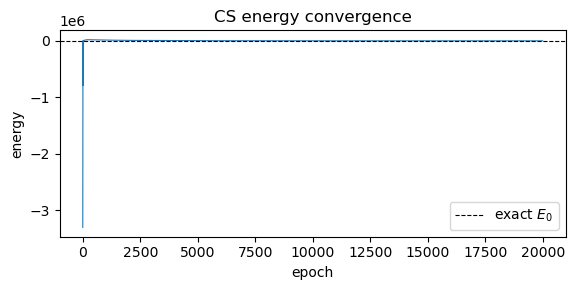

In [7]:
energies = np.array([float(s.energy) for s in result.history])
plt.figure(figsize=(6, 3))
plt.plot(energies, lw=0.8)
plt.axhline(E_exact_total, color='k', ls='--', lw=0.8, label='exact $E_0$')
plt.xlabel('epoch'); plt.ylabel('energy'); plt.legend()
plt.title('CS energy convergence'); plt.tight_layout(); plt.show()

In [8]:
result_rerun = run_cs(L, init_params=result.final_params, n_epochs=5_000, optimizer=optax.adam(learning_rate=1e-4))

Running CS: N=30, L=0.8, model=mlp_jastrow  (exact E0=726.0000)


100%|██████████| 5000/5000 [03:54<00:00, 21.30it/s, E=726.2245, sigma_E=5.9134]         


── training summary ────────────────────────────────────────
epochs ran       : 5000   (3m 46.2s wall, 515 parameters)
final epoch      : E = 726.226624 ± 2.24e-01   σ_E = 14.3650
best epoch (    1) : E = 141.861298 ± 2.21e+02   σ_E = 14175.4932
acceptance (tail): 0.500
best snapshot    : epoch 4191 (select metric = 3.68986; 5000 kept — result.best_params() to load)
────────────────────────────────────────────────────────────


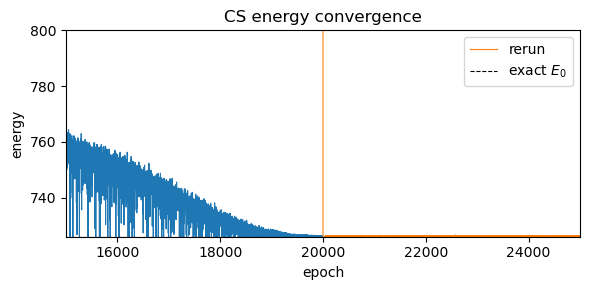

In [9]:
energies = np.array([float(s.energy) for s in result.history])
epochs = np.arange(len(energies))
plt.figure(figsize=(6, 3))
plt.plot(epochs, energies, lw=0.8)
energies_rerun = np.array([float(s.energy) for s in result_rerun.history])
epochs_rerun = np.arange(len(energies_rerun)) + len(energies)
plt.plot(epochs_rerun, energies_rerun, lw=0.8, label='rerun')
plt.axhline(E_exact_total, color='k', ls='--', lw=0.8, label='exact $E_0$')
plt.xlabel('epoch'); plt.ylabel('energy'); plt.legend()
plt.ylim(E_exact_total, 800)
plt.xlim(15000, len(energies) + len(energies_rerun))
plt.title('CS energy convergence'); plt.tight_layout(); plt.show()

In [10]:
def get_param_statistics(params):
    """Return mean and std of the parameters in a dict."""
    params = params['params']
    lambda_param = params['jastrow']['lambda']
    envelope_params = params['envelope']
    network_params, _ = jax.tree_util.tree_flatten(params["network"])
    network_params = [p.ravel() for p in network_params]
    vec_network_params = np.concatenate([np.array(p) for p in network_params])
    return {"network": {
        'mean': np.mean(vec_network_params),
        'std': np.std(vec_network_params),
        'min': np.min(vec_network_params),
        'max': np.max(vec_network_params),
    },
            "envelope": {
        'value': {k: f"{float(v):.4f}" for k, v in envelope_params.items()},
    },
            "lambda": {
        'value': f"{float(lambda_param):.4f}",
    }}

print(get_param_statistics(result.final_params))
print(get_param_statistics(result_rerun.final_params))

{'network': {'mean': np.float32(0.005271182), 'std': np.float32(0.18913639), 'min': np.float32(-0.5139871), 'max': np.float32(0.55798423)}, 'envelope': {'value': {'alpha': '0.7089'}}, 'lambda': {'value': '0.8015'}}
{'network': {'mean': np.float32(0.0052927844), 'std': np.float32(0.18908133), 'min': np.float32(-0.5133866), 'max': np.float32(0.55738294)}, 'envelope': {'value': {'alpha': '0.7083'}}, 'lambda': {'value': '0.8021'}}


In [11]:
all_epochs = sorted([snap["step"] for snap in result_rerun.snapshots])
nums = np.array(range(len(all_epochs)))
mask = all_epochs-nums
